# Modelo Llama-3.2-1B-Instruct
A continuación, mostramos el procedimiento realizado para evaluar las técnicas de *Zero-shot* y *Few Shot* para el conjunto de datos **Financial Phrase Bank** utilizando el modelo Llama-3.2-1B-Instruct

In [ ]:
!pip install -q transformers accelerate bitsandbytes datasets scikit-learn torch huggingface_hub

In [ ]:
# instalamos las librerías necesarias
import pandas as pd
import torch
from transformers import pipeline
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, BertForMaskedLM
from sklearn.metrics import f1_score, classification_report
from tqdm import tqdm
from huggingface_hub import login
from google.colab import userdata

# incluimos tokens para
hf_token = userdata.get('hf_token')
login(token=hf_token)

In [ ]:
data = pd.read_csv('Sentences_AllAgree.csv')
data.head()

In [ ]:
model_id = "meta-llama/Llama-3.2-1B-Instruct"
pipe = pipeline(
    "text-generation",
    model=model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

In [ ]:
def clean_pipeline_prediction(output_list):
    """Extracts and cleans the sentiment from the pipeline output."""
    if output_list and len(output_list) > 0 and 'generated_text' in output_list[0]:
        assistant_response = output_list[0]['generated_text'][-1]
        if 'content' in assistant_response:
            response_text = assistant_response['content'].lower().strip()
            if 'positive' in response_text:
                return 'positive'
            elif 'negative' in response_text:
                return 'negative'
            elif 'neutral' in response_text:
                return 'neutral'
    return 'unknown'

In [ ]:
predicted_sentiments = []

for index, row in data.iterrows():
    sentence = row['sentences']
    messages = [
        {"role": "system", "content": "You're an expert financial sentiment analyst, and you make no mistakes on your choices. Also you only answer with positive, negative or neutral"},
        {"role": "user", "content": f"Sentence: {sentence} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"},
    ]
    outputs = pipe(
        messages,
        max_new_tokens=5,
    )
    predicted_sentiment = clean_pipeline_prediction(outputs)
    predicted_sentiments.append(predicted_sentiment)

print(f"Total predictions: {len(predicted_sentiments)}")
print("First 5 predicted sentiments:", predicted_sentiments[:5])

In [ ]:
predicted_sentiments_df = pd.DataFrame(predicted_sentiments, columns=['predicted_sentiment'])
display(predicted_sentiments_df.head())

In [ ]:
# predicted_sentiments_df.to_csv('predicted_sentiments.csv', index=False)
# print("Predicted sentiments saved to 'predicted_sentiments.csv'")

# Usando técnica de Few Shot

In [ ]:
# Find an example for each sentiment (assuming labels are 0:negative, 1:neutral, 2:positive)
positive_example = data[data['labels'] == 2].iloc[0]
neutral_example = data[data['labels'] == 1].iloc[0]
negative_example = data[data['labels'] == 0].iloc[0]

few_shot_examples = [
    {
        "role": "user",
        "content": f"Sentence: {positive_example['sentences']} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"
    },
    {"role": "assistant", "content": "positive"},
    {
        "role": "user",
        "content": f"Sentence: {neutral_example['sentences']} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"
    },
    {"role": "assistant", "content": "neutral"},
    {
        "role": "user",
        "content": f"Sentence: {negative_example['sentences']} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"
    },
    {"role": "assistant", "content": "negative"}
]

In [ ]:
fewshot_predicted_sentiments = []

for index, row in data.iterrows():
    sentence = row['sentences']

    # Combine system message, few-shot examples, and the current sentence for prediction
    messages_with_few_shot = [
        {"role": "system", "content": "You're an expert financial sentiment analyst, and you make no mistakes on your choices. Also you only answer with positive, negative or neutral"}
    ] + few_shot_examples + [
        {"role": "user", "content": f"Sentence: {sentence} Clasiffy the sentiment of this sentence as Positive, Negative or Neutral, CHOOSE just one"}
    ]

    outputs = pipe(
        messages_with_few_shot,
        max_new_tokens=5,
    )
    fewshot_predicted_sentiment = clean_pipeline_prediction(outputs)
    fewshot_predicted_sentiments.append(fewshot_predicted_sentiment)

print(f"Total Few-Shot predictions: {len(fewshot_predicted_sentiments)}")
print("First 5 Few-Shot predicted sentiments:", fewshot_predicted_sentiments[:5])


In [ ]:
fewshot_predicted_sentiments_df = pd.DataFrame(fewshot_predicted_sentiments, columns=['fewshot_predicted_sentiment'])
display(fewshot_predicted_sentiments_df.head())

In [ ]:
fewshot_predicted_sentiments_df.to_csv('fewshot_predicted_sentiments.csv', index=False)
print("Few-shot predicted sentiments saved to 'fewshot_predicted_sentiments.csv'")

# Análisis de resultados

In [23]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('Sentences_AllAgree.csv')
df_few_shot = pd.read_csv('fewshot_predicted_sentiments_llama32_1b_instruct.csv')
df_zero_shot = pd.read_csv('predicted_sentiments_llama32_1B_instruct_zero_shot.csv')

In [25]:
print(df.size)
print(df_few_shot.size)
print(df_zero_shot.size)

4528
2264
2264


In [26]:
# Convertimos los datos a numericos para tener una sola versión de los datos
level_map = {
    'neutral' : 1,
    'positive' : 2,
    'negative' : 0
}

df_few_shot['fewshot_predicted_sentiment'] = df_few_shot['fewshot_predicted_sentiment'].map(level_map)
df_zero_shot['predicted_sentiment'] = df_zero_shot['predicted_sentiment'].map(level_map)

In [28]:
df_concat1 = pd.concat([df, df_few_shot], axis=1)
df_concat2 = pd.concat([df_concat1, df_zero_shot], axis=1)
df_final = df_concat2
df_final.head()

,sentences,labels,fewshot_predicted_sentiment,predicted_sentiment
0,"According to Gran , the company has no plans t...",1,2,1.0
1,"For the last quarter of 2010 , Componenta 's n...",2,2,1.0
2,"In the third quarter of 2010 , net sales incre...",2,2,1.0
3,Operating profit rose to EUR 13.1 mn from EUR ...,2,2,1.0
4,"Operating profit totalled EUR 21.1 mn , up fro...",2,2,1.0


In [31]:
df_final.isnull().sum()

,0
sentences,0
labels,0
fewshot_predicted_sentiment,0
predicted_sentiment,36


In [33]:
# Realizamos el reporte de resultados
reporte_few_shot = classification_report(df_final['labels'], df_final['fewshot_predicted_sentiment'])
reporte_zero_shot = classification_report(df_final['labels'], df_final['predicted_sentiment'].fillna(1))

print("Reporte de Zero-Shot:")
print(reporte_zero_shot)

print("\nReporte de Few-Shot:")
print(reporte_few_shot)

Reporte de Zero-Shot:
              precision    recall  f1-score   support

           0       0.30      0.21      0.25       303
           1       0.64      0.84      0.72      1391
           2       0.32      0.13      0.18       570

    accuracy                           0.57      2264
   macro avg       0.42      0.39      0.39      2264
weighted avg       0.51      0.57      0.52      2264


Reporte de Few-Shot:
              precision    recall  f1-score   support

           0       0.88      0.15      0.26       303
           1       0.78      0.23      0.35      1391
           2       0.31      0.98      0.47       570

    accuracy                           0.40      2264
   macro avg       0.66      0.45      0.36      2264
weighted avg       0.68      0.40      0.37      2264



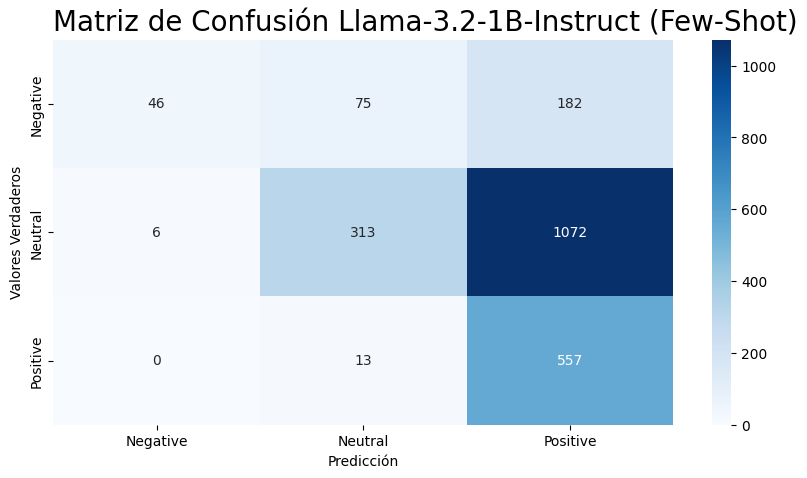

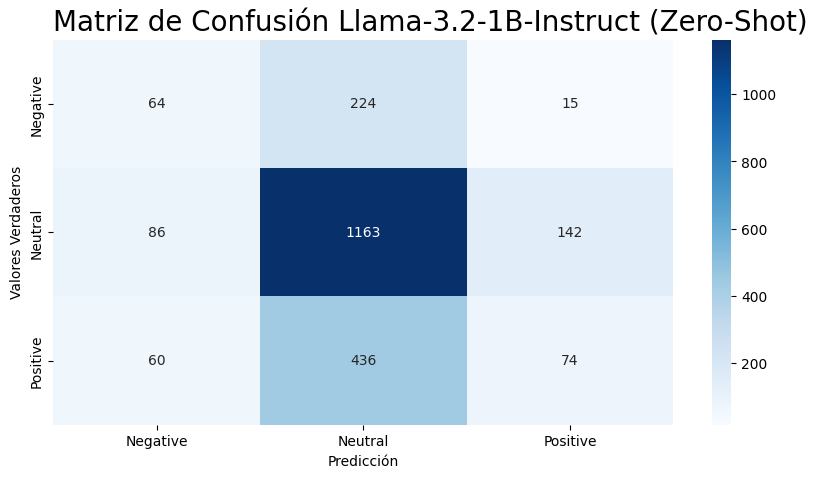

In [35]:
# Graficamos la matriz de confusión
matriz_confusion_few_shot = confusion_matrix(df_final['labels'], df_final['fewshot_predicted_sentiment'])
matriz_confusion_zero_shot = confusion_matrix(df_final['labels'], df_final['predicted_sentiment'].fillna(1))

plt.figure(figsize=(10, 5))
sns.heatmap(matriz_confusion_few_shot, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Matriz de Confusión Llama-3.2-1B-Instruct (Few-Shot)', fontsize=20, loc='left')
plt.xlabel('Predicción')
plt.ylabel('Valores Verdaderos')
plt.show()

plt.figure(figsize=(10, 5))
sns.heatmap(matriz_confusion_zero_shot, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Matriz de Confusión Llama-3.2-1B-Instruct (Zero-Shot)', fontsize=20, loc='left')
plt.xlabel('Predicción')
plt.ylabel('Valores Verdaderos')
plt.show()